# 2교시 실습 — 타이타닉, 누가 살아남았나? 🕵️🚢

> **사용법**
> - 🔵 **수업** = 강사와 함께 실행하는 셀 · 🟡 **셀프** = 집에서 직접 채울 셀(빈칸 `____`)
> - 이 파일은 **연습용(`_blank`)** 입니다. 막히면 정답본(`_solution`)과 대조하세요.
> - 정답본에는 **실행 결과 + 💡해석**이 셀마다 달려 있습니다.

---

## 📭 오늘의 미션

여러분은 오늘 막 **데이터 분석가**로 첫 출근을 했습니다.
팀장님이 책상에 파일 하나를 툭 던지며 말합니다.

> *"이거 1912년 타이타닉호 승객 명단이야. 누가 살아남았는지 데이터에 단서가 있을 거야.*
> *데이터랑 인사부터 하고 → 정리하고 → 누가 살았는지 분석해서 → 그림까지 그려서 보고해줘. 오늘 안에!"*

오늘 우리는 분석가의 **하루 전체**를 따라갑니다:

```
 ① 인사       ② 정제        ③ 분석          ④ 시각화      ⑤ 해석
첫인상 보기 → 빈칸 채우기 → 그룹별 생존율 →  그림으로 →  "누가, 왜"
```

겁먹지 마세요. 한 칸씩 천천히 가면 됩니다. 출발! 🚀

## ① 인사 (1) — 워밍업: 노트북 다루기  🔵

노트북은 **셀(cell)** 단위로 코드를 실행합니다.
셀을 클릭하고 **Shift + Enter** 를 누르면 실행되고, 결과가 바로 아래에 나옵니다. 몸풀기부터.

In [1]:
print("첫 출근 완료!")   # 따옴표 안 글자를 화면에 그대로 출력
1 + 1                    # 마지막 줄의 계산 결과(2)는 자동으로 표시됨

첫 출근 완료!


2

💡 **해석**: 코드를 쓰면 바로 아래에 결과가 나옵니다. 마지막 줄의 값(`2`)은 자동으로 출력돼요. **쓰고, 바로 확인** — 이게 노트북의 매력입니다.

데이터 분석의 필수 도구 **판다스(pandas)** 와 예제 데이터 도구 **seaborn** 을 불러옵니다.
`import ... as ...` 는 "이 도구를 이런 별명으로 쓸게" 라는 뜻이에요.  🔵

In [2]:
import pandas as pd      # 표(데이터)를 다루는 도구, 별명 pd
import seaborn as sns      # 예제 데이터 + 시각화 도구
import matplotlib.pyplot as plt   # 그래프 그리는 도구

# --- 그래프 한글 깨짐 방지: 아래는 '그대로 실행'만 하세요 (코랩에서 폰트 자동 설치) ---
import os, urllib.request                       # 파일 확인·다운로드용 기본 도구
from matplotlib import font_manager as fm       # 폰트 등록 담당 도구
_FONT_URL = "https://raw.githubusercontent.com/acho98/gunyang-data/main/BMDOHYEON.ttf"   # 한글 폰트 내려받을 주소
def set_korean_font():                          # 한글 폰트를 켜주는 함수 정의
    cands = ["../data/BMDOHYEON.ttf", "data/BMDOHYEON.ttf", "BMDOHYEON.ttf"]   # 폰트가 있을 만한 후보 위치들
    if not any(os.path.exists(p) for p in cands):   # 후보 중 하나도 없으면
        try: urllib.request.urlretrieve(_FONT_URL, "BMDOHYEON.ttf")   # 인터넷에서 폰트 다운로드 시도
        except Exception: pass                  # 실패해도 그냥 넘어감
    for p in cands:                             # 후보 위치를 하나씩 확인
        if os.path.exists(p):                   # 그 위치에 폰트 파일이 실제로 있으면
            try:
                fm.fontManager.addfont(p)       # 폰트를 matplotlib에 등록
                plt.rcParams["font.family"] = fm.FontProperties(fname=p).get_name()   # 기본 글꼴로 지정
                plt.rcParams["axes.unicode_minus"] = False   # 마이너스(-) 기호 깨짐 방지
                return                          # 성공했으니 함수 종료
            except Exception: pass
    print("(안내) 한글 폰트를 못 찾았어요. 영문 라벨 차트는 정상입니다.")   # 모두 실패 시 안내
set_korean_font()                               # 위에서 만든 함수를 실제로 실행

print("pandas 버전:", pd.__version__)            # 판다스 버전 출력 = 준비 완료 확인

pandas 버전: 2.2.3


💡 **해석**: 에러 없이 버전이 찍히면 준비 끝. 앞으로 거의 모든 분석이 이 몇 줄에서 시작합니다.

## ① 인사 (2) — 타이타닉과 첫인사  🔵

데이터를 불러옵니다. seaborn 내장 데이터라 **다운로드 없이** 바로 옵니다.

In [3]:
df = sns.load_dataset("titanic")   # 타이타닉 예제 데이터를 불러와 df라는 상자에 담기
print("불러오기 완료! 변수 이름은 df 입니다.")   # 안내 문구 출력

불러오기 완료! 변수 이름은 df 입니다.


💡 **해석**: `df` 라는 상자에 표 전체를 담았습니다. 이제부터 `df.무엇()` 으로 이 표를 들여다봅니다. (df = **D**ata**F**rame, 표라는 뜻)

### `head()` — 일단 눈으로 보기  🔵
백 마디 설명보다 직접 보는 게 빠릅니다. 맨 위 5줄만.

In [4]:
df.head()   # 표의 맨 위 5줄만 미리 보기

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


💡 **해석**: 한 줄이 **승객 한 명**입니다. 컬럼(열)을 읽어보면 —
- `survived`: 생존(1)/사망(0)  · `pclass`: 객실 등급(1·2·3등석)  · `sex`: 성별
- `age`: 나이  · `fare`: 요금  · `class`/`who`/`alive`: 같은 정보를 글자로

벌써 "등급·성별·나이·요금"이 생존과 관련 있어 보이죠? 이게 **첫인상**입니다.

### `shape` — 규모 파악  🟡
몇 명이 탔고(행), 정보는 몇 가지(열)일까요?
> 💡 힌트: `df.shape` → `(행, 열)`

In [5]:
df.shape   # (행 수, 열 수) 튜플로 데이터 크기 확인

(891, 15)

💡 **해석**: `(891, 15)` — 승객 **891명**, 정보 **15개**. 사람이 891줄을 눈으로 다 보긴 어렵죠. 그래서 요약 도구가 필요합니다.

### `info()` — 신상명세서 + 빈 칸 찾기  🔵
각 컬럼의 **타입**과 **빈 칸(결측치)** 을 한눈에. 분석가가 가장 먼저 확인하는 것 중 하나예요.

In [6]:
df.info()   # 각 컬럼의 타입과 빈 칸(결측치) 개수를 한눈에

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


💡 **해석**: `Non-Null Count` 를 보세요. 전체 891명인데 —
- `age` 는 **714** 만 차 있음 → **177명의 나이가 비어 있다!**
- `deck` 은 **203** 뿐 → 거의 다 비었음

이렇게 **빈 칸을 미리 발견**하는 게 중요합니다. (채울지 버릴지는 오늘 ②정제에서!)

### `describe()` — 숫자 요약  🟡
숫자 컬럼들의 평균·최소·최대·중앙값(50%)을 한 번에.
> 💡 힌트: `df.describe()`

In [7]:
df.describe()   # 숫자 컬럼들의 평균·최소·최대·중앙값을 한 번에

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


💡 **해석**: (1교시 통계가 여기서 쓰입니다!)
- `age` 평균 ≈ **29.7세**, 최소 **0.42세**(생후 5개월 아기!), 최대 **80세**
- `fare`(요금) 평균 ≈ 32인데 최대 **512** → 한쪽으로 크게 치우침 = **평균의 함정** 가능성!

→ 요금은 평균보다 **중앙값(50% = 14.45)** 이 현실에 가깝습니다. 1교시 "평균 vs 중앙값" 기억나죠?

### `value_counts()` — 범주 세기  🟡
범주형 변수는 "각 값이 몇 번 나오나"를 셉니다. 성별과 객실등급을 세어보세요.
> 💡 힌트: `df["sex"].value_counts()`

In [8]:
df["sex"].value_counts()   # 성별 칸에서 각 값(남/여)이 몇 번 나오는지 세기

sex
male      577
female    314
Name: count, dtype: int64

In [9]:
df["class"].value_counts()   # 객실 등급별로 각 등급 인원이 몇 명인지 세기

class
Third     491
First     216
Second    184
Name: count, dtype: int64

💡 **해석**:
- 남성 **577명** vs 여성 **314명** → 남성이 훨씬 많았다
- 3등석 **491명** > 1등석 216 > 2등석 184 → **3등석이 절반 이상**

"남성·3등석이 많은 배". 생존율과 연결하면? → 잠시 뒤 ③분석에서!

## ① 인사 (3) — 궁금한 곳 콕 집어 보기

큰 그림을 봤으니 이제 **특정 부분**을 자세히. 분석가의 기본 손놀림 몇 가지를 익힙니다.

### 평균 구하기  🟡
평균 나이와 평균 요금을 구해봅시다.
> 💡 힌트: `df["age"].mean()`

In [10]:
print("평균 나이:", round(df["age"].mean(), 1))   # 나이 칸 평균을 소수 1자리로 반올림해 출력
print("평균 요금:", round(df["fare"].mean(), 1))   # 요금 칸 평균을 소수 1자리로 반올림해 출력

평균 나이: 29.7
평균 요금: 32.2


💡 **해석**: 평균 나이 ≈ 29.7세(젊은 편), 평균 요금 ≈ 32.2. 단, 요금은 극단값(512!)이 평균을 끌어올렸습니다. **평균 하나만 믿지 말 것** (1교시 평균의 함정).

### 정렬해서 보기 — `sort_values()`  🟡
요금이 가장 비쌌던 승객 5명은? 요금 높은 순으로.
> 💡 힌트: `df.sort_values("fare", ascending=False)`

In [11]:
df.sort_values("fare", ascending=False).head()   # 요금 높은 순으로 정렬(ascending=False=큰 값부터) 후 상위 5명

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
258,1,1,female,35.0,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True
737,1,1,male,35.0,0,0,512.3292,C,First,man,True,B,Cherbourg,yes,True
679,1,1,male,36.0,0,1,512.3292,C,First,man,True,B,Cherbourg,yes,False
88,1,1,female,23.0,3,2,263.0000,S,First,woman,False,C,Southampton,yes,False
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False


💡 **해석**: 요금 **512.3** 승객들이 맨 위 — 모두 **1등석**, 그리고 **생존(survived=1)**! 비싼 표 = 높은 생존, 단서가 쌓입니다. `ascending=False` 는 '큰 값부터'예요.

### 조건으로 걸러내기 — 필터링  🔵
"18세 미만 어린이는 몇 명?" 조건을 만족하는 행만 골라냅니다.

In [12]:
children = df[df["age"] < 18]   # 나이가 18 미만인 행(어린이)만 골라 따로 담기
print("18세 미만 어린이 수:", len(children), "명")   # 골라낸 행 개수 = 어린이 수

18세 미만 어린이 수: 113 명


💡 **해석**: `df[조건]` 은 조건이 참인 행만 남깁니다. 어린이는 약 113명. "여성과 어린이 먼저"라는 구조 원칙과 연결되는 단서!

## ② 정제 (Clean) — 나이의 빈 칸 채우기  🟡

`info()`에서 봤듯 `age`에 **177명의 빈 칸**이 있었죠. 나이는 우리 분석의 핵심이라 버릴 수 없으니 **채워야** 합니다.
극단값이 많지 않은 나이는 **중앙값(median)** 으로 채우는 게 무난합니다. 채운 뒤 결측이 **0이 됐는지** 확인하세요.
> 💡 힌트: `df["age"].fillna(df["age"].median())`  *(자세한 정제 기법은 3교시에서!)*

In [13]:
before = df["age"].isnull().sum()   # 채우기 전, 비어 있는(결측) 나이 개수 세기
df["age"] = df["age"].fillna(df["age"].median())   # 빈 칸을 나이 중앙값으로 채워 다시 저장
after = df["age"].isnull().sum()    # 채운 뒤 남은 결측 개수 세기 (0이어야 함)
print(f"나이 결측치: {before}개 → {after}개")   # 채우기 전→후 결측 개수 비교 출력
print("채우는 데 쓴 중앙값:", df["age"].median(), "세")   # 실제로 채운 값(중앙값) 확인

나이 결측치: 177개 → 0개
채우는 데 쓴 중앙값: 28.0 세


💡 **해석**: 결측 **177개 → 0개**! 채운 값은 중앙값 **28세**. (평균 29.7세보다 중앙값 28세가 극단 나이의 영향을 덜 받아 무난합니다.) 이제 891명 전원의 나이가 채워져 분석에 쓸 수 있습니다.

## ③ 분석 (Group) — 누가 더 살아남았나  🔵

분석의 심장. **`groupby`** 로 "그룹별 생존율"을 구합니다.
`survived`가 1/0이라 평균(`mean`)을 내면 그게 곧 **생존율**입니다(0.63 = 63% 생존).

먼저 **객실 등급(pclass)** 별 생존율.

In [14]:
df.groupby("pclass")["survived"].mean().round(3)   # 등급별로 묶어 생존(1/0) 평균=생존율, 소수 3자리

pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64

💡 **해석**: **1등석 63% · 2등석 47% · 3등석 24%.** 등급이 낮을수록 생존율이 뚝뚝 떨어집니다. 비싼 표를 산 사람이 더 많이 살았다 — 슬프지만 데이터의 사실입니다.

### 직접 분석 — 성별 생존율  🟡
**성별(`sex`)** 로 생존율을 직접 구해보세요. "여성과 어린이 먼저"가 사실이었을까요?
> 💡 힌트: `df.groupby("sex")["survived"].mean()`

In [15]:
df.groupby("sex")["survived"].mean().round(3)   # 성별로 묶어 생존율 계산, 소수 3자리

sex
female    0.742
male      0.189
Name: survived, dtype: float64

💡 **해석**: **여성 74% vs 남성 19%.** 무려 4배 가까운 차이! 등급보다 **성별의 영향이 더 커 보이는데** — 정말 그런지 다음 셀에서 둘을 겹쳐 봅니다.

### 두 조건을 겹치면? — 등급 × 성별  🔵
진짜 분석가는 여기서 멈추지 않습니다. **"등급과 성별을 동시에"** 보면 더 깊은 진실이 나옵니다.

In [16]:
df.groupby(["sex", "pclass"])["survived"].mean().round(3)   # 성별 × 등급 두 조건으로 동시에 묶어 생존율 계산

sex     pclass
female  1         0.968
        2         0.921
        3         0.500
male    1         0.369
        2         0.157
        3         0.135
Name: survived, dtype: float64

💡 **해석**: 충격적인 한 줄 — **3등석 여성(50%)이 1등석 남성(37%)보다 더 살았습니다.**
- 여성: 1등석 **97%** · 2등석 92% · 3등석 **50%**
- 남성: 1등석 **37%** · 2등석 16% · 3등석 **14%**

즉 "돈(등급)"보다 "**성별**"이 생사를 더 강하게 갈랐습니다. 등급만 봤다면 놓쳤을 진실 — **나눠 보기(1교시)의 위력**!

## ④ 시각화 (Visualize) — 숫자를 그림으로  🔵

표의 숫자는 회의에서 설득력이 약합니다. 등급별 생존율을 **막대그래프**로 바꿉니다.
*(차트는 4교시에서 본격적으로 배웁니다 — 오늘은 맛보기!)*

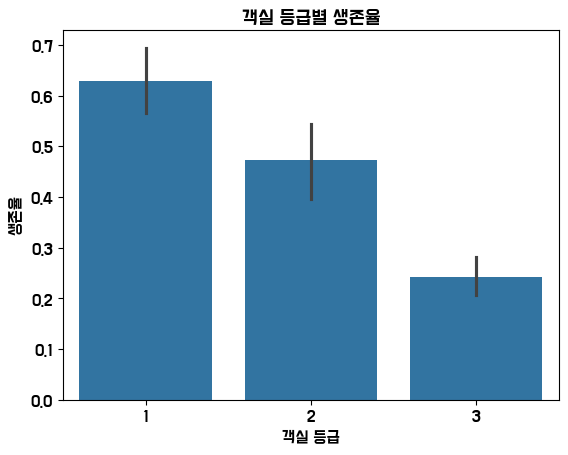

In [17]:
sns.barplot(data=df, x="pclass", y="survived")   # x=등급, y=생존율 막대그래프 그리기
plt.title("객실 등급별 생존율")   # 그래프 제목 달기
plt.xlabel("객실 등급"); plt.ylabel("생존율")   # 가로축·세로축 이름 달기
plt.show()   # 완성된 그래프를 화면에 표시

💡 **해석**: 1→2→3등석으로 가며 막대가 **계단처럼 내려갑니다.** 숫자 `0.63, 0.47, 0.24`를 말할 때보다, 이 막대 한 장이 회의실에서 훨씬 강력합니다.

### 직접 시각화 ① — 성별 × 등급 한 그림에  🟡
③에서 발견한 "성별이 더 중요"를 한 장으로. 막대에 `hue="sex"` 를 더하면 등급별로 남/녀 막대가 나란히.
> 💡 힌트: `sns.barplot(data=df, x="pclass", y="survived", hue="sex")`

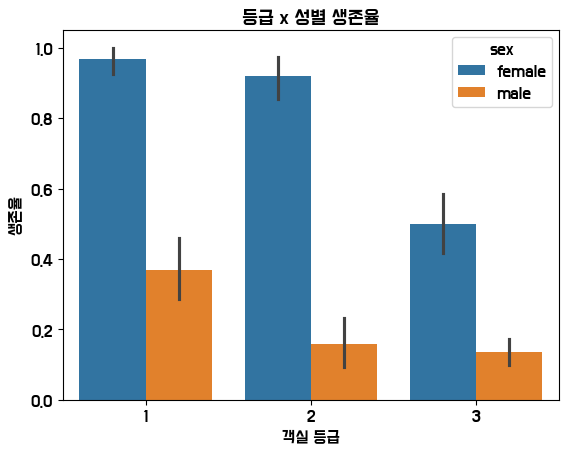

In [18]:
sns.barplot(data=df, x="pclass", y="survived", hue="sex")   # 등급별 막대를 성별(hue)로 나눠 나란히
plt.title("등급 x 성별 생존율")   # 그래프 제목 달기
plt.xlabel("객실 등급"); plt.ylabel("생존율")   # 가로축·세로축 이름 달기
plt.show()   # 완성된 그래프를 화면에 표시

💡 **해석**: **모든 등급에서 여성(파란 막대)이 남성보다 높습니다.** 심지어 3등석 여성 막대가 1·2등석 남성 막대보다 높죠. 색(`hue`) 한 줄로 "성별 > 등급"이 그림 한 장에 담겼습니다.

### 직접 시각화 ② — 생존/사망별 나이 분포  🟡
산 사람과 죽은 사람의 **나이 분포**가 다를까요? 박스플롯으로 비교하세요.
> 💡 힌트: `sns.boxplot(data=df, x="survived", y="age")`

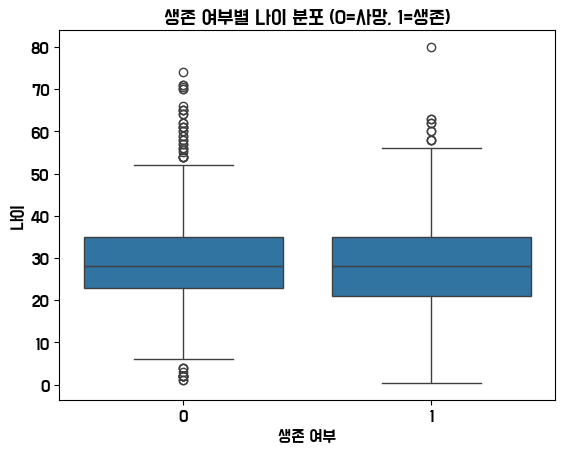

In [19]:
sns.boxplot(data=df, x="survived", y="age")   # 생존 여부별 나이 분포를 박스플롯으로
plt.title("생존 여부별 나이 분포 (0=사망, 1=생존)")   # 그래프 제목 달기
plt.xlabel("생존 여부"); plt.ylabel("나이")   # 가로축·세로축 이름 달기
plt.show()   # 완성된 그래프를 화면에 표시

💡 **해석**: 두 그룹의 나이 중앙값은 **크게 다르지 않습니다**(둘 다 20대 후반). 즉 나이만으로는 생사가 뚜렷이 안 갈렸어요 — 다만 생존 쪽에 아주 어린 아이들이 보입니다. **"나이는 성별·등급만큼 결정적이진 않았다"** — 가설이 빗나가는 것도 중요한 발견!

## ⑤ 해석 (Interpret) — "그래서 무엇을 알았나"  🟡

**가장 중요한 단계.** 코드는 숫자를 줄 뿐, *결론을 내는 건 사람*입니다.
아래 셀은 핵심 숫자를 한 번에 출력합니다. 빈칸을 채워 실행한 뒤, `[해석]` 에 **내 결론을 한 문단** 적어보세요.

In [20]:
c1 = df.groupby("pclass")["survived"].mean()   # 등급별 생존율을 c1에 저장
c2 = df.groupby("sex")["survived"].mean()      # 성별 생존율을 c2에 저장
print("=== 타이타닉 생존 분석 요약 ===")       # 요약 제목 출력
print(f"전체 생존율      : {df['survived'].mean():.0%}")   # 전체 생존율을 % 형태로 출력
print(f"1등석 vs 3등석   : {c1[1]:.0%}  vs  {c1[3]:.0%}")   # 1등석·3등석 생존율 비교
print(f"여성 vs 남성     : {c2['female']:.0%}  vs  {c2['male']:.0%}")   # 여성·남성 생존율 비교
print(f"3등석 여성        : {df[(df.sex=='female')&(df.pclass==3)]['survived'].mean():.0%}")   # 3등석 여성만 골라 생존율
print(f"1등석 남성        : {df[(df.sex=='male')&(df.pclass==1)]['survived'].mean():.0%}")   # 1등석 남성만 골라 생존율
print()   # 보기 좋게 빈 줄 한 칸
print("[해석] 성별이 등급보다 생존을 더 강하게 갈랐다. 여성(74%)은 남성(19%)의 약 4배,")
print("       특히 3등석 여성(50%)이 1등석 남성(37%)보다도 더 살아남았다.")

=== 타이타닉 생존 분석 요약 ===
전체 생존율      : 38%
1등석 vs 3등석   : 63%  vs  24%
여성 vs 남성     : 74%  vs  19%
3등석 여성        : 50%
1등석 남성        : 37%

[해석] 성별이 등급보다 생존을 더 강하게 갈랐다. 여성(74%)은 남성(19%)의 약 4배,
       특히 3등석 여성(50%)이 1등석 남성(37%)보다도 더 살아남았다.


💡 **모범 해석**: *"타이타닉 생존을 가른 가장 큰 요인은 **성별**이었다. 여성 생존율(74%)은 남성(19%)의 약 4배였고, 객실 등급도 영향을 줬지만(1등석 63% vs 3등석 24%) 성별만큼 강하지는 않았다. 결정적 증거는 **3등석 여성(50%)이 1등석 남성(37%)보다 더 많이 살아남았다**는 점 — '여성과 어린이 먼저' 원칙이 돈(등급)보다 우선했음을 보여준다. 나이는 생사를 뚜렷이 가르지 못했다."*

**숫자 → 한 문단의 결론**으로 잇는 것이 분석의 끝이자 핵심입니다.

## 🎯 미션 완료 — 팀장님께 보고

오늘 여러분은 분석가의 **하루 전체**를 처음부터 끝까지 직접 해냈습니다:

```
 ① 인사          ② 정제           ③ 분석             ④ 시각화        ⑤ 해석
첫인상 5종 →   나이 중앙값 28 →   등급·성별 생존율 →  막대·박스플롯 →  "성별 > 등급"
              결측 177→0              나눠보기                        한 문단 결론
```

그리고 **데이터가 가설을 뒤집는 순간**(3등석 여성 > 1등석 남성)을 직접 목격했습니다.
이게 분석의 진짜 재미예요 — 미리 정한 답이 아니라, **데이터가 말하게 하는 것.**

| 도구 | 무엇을 알려주나 |
|---|---|
| `head/shape/info/describe` | 데이터 첫인상 + 빈 칸 |
| `value_counts` | 범주별 개수 |
| `fillna` | 결측치 채우기(정제) |
| `groupby(...).mean()` | **그룹별 생존율(분석의 심장)** |
| `barplot / boxplot` | 그림으로 비교 |

> ## "도구는 변해도, 좋은 질문을 던지고 결과를 해석하는 힘은 사람의 몫이다."

> 🏠 **셀프스터디**: 같은 5단계를 **다른 데이터**로 직접 돌려보세요.
> `df = sns.load_dataset("penguins")` 로 바꿔, "종(species)별 몸무게는 어떻게 다를까?"를 `groupby`·`boxplot`으로 분석해보면 똑같이 됩니다. 방법은 늘 같아요! 🚀